In [1]:
#Section 1: Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

from utils import load_data, prepare_master_tables, calculate_kpis
from utils import (
    plot_line_chart, plot_bar_chart, plot_histogram,
    plot_scatter, plot_boxplot, plot_heatmap,
    plot_multilayer_arrivals_fx, plot_faceted_top_markets,
    plot_interactive_market_comparison
)

sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")


In [2]:
#Section 2: Load Data
raw_data = load_data(DATA_DIR)
len(raw_data), sorted(raw_data.keys())[:5]


(26,
 ['1.tourist-arrivals-and-average-length-of-stay-in-nepal-19642024',
  '10.tourist-arrival-by-entry-points-land-2024',
  '11.tourist-arrival-by-purpose-of-visit-19932024',
  '12number-of-trekkers-in-different-trekking-areas-20012024',
  '13number-of-foreign-visitors-to-national-parks-and-conservation-areascleaned'])

In [3]:
#Section 3: Cleaning Summary
dataset_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "cols": df.shape[1],
            "columns": ", ".join(df.columns[:8])
        }
        for name, df in raw_data.items()
    ]
).sort_values("dataset")

dataset_summary


,dataset,rows,cols,columns
0,1.tourist-arrivals-and-average-length-of-stay-...,366,5,"year, value, metric, type, ad_year"
1,10.tourist-arrival-by-entry-points-land-2024,96,4,"entry_point, month, value, month_num"
2,11.tourist-arrival-by-purpose-of-visit-19932024,257,4,"year, category, value, ad_year"
3,12number-of-trekkers-in-different-trekking-are...,216,4,"year, region, value, ad_year"
4,13number-of-foreign-visitors-to-national-parks...,270,4,"conservation_area, year, visitors, ad_year"
5,14.monthly-visitors-excluding-indian-citizens-...,168,6,"month, year, value, ad_year, month_num, date"
6,15.indian-visitors-to-lumbini-20142024,132,6,"month, year, value, ad_year, month_num, date"
7,16.third-country-visitors-to-lumbini-excluding...,132,6,"month, year, value, ad_year, month_num, date"
8,17.gross-foreign-exchange-earnings-from-touris...,100,4,"year, metric, value, ad_year"
9,18foreign-exchange-earnings-from-tourism-fy-20...,115,4,"year, metric, value, ad_year"


In [4]:
#Section 4: Feature Engineering + Merging
tables = prepare_master_tables(raw_data)

annual_arrivals = tables["annual_arrivals"]
monthly_arrivals = tables["monthly_arrivals"]
nationality_yearly = tables["nationality_yearly"]
nationality_monthly = tables["nationality_monthly"]
purpose_yearly = tables["purpose_yearly"]
parks_yearly = tables["parks_yearly"]
master_yearly = tables["master_yearly"]

master_yearly.head()


,year,third_country,indian,change,ad_year,total_arrivals,annual_growth,avg_stay,by_air,by_land,...,park_visitors,trekkers,holiday_arrivals,complaints,yield_per_arrival,park_pressure_index,trekking_share_pct,holiday_share_pct,complaints_per_100k_arrivals,bed_capacity_per_1000_arrivals
0,1996,271101,122512,8.3,1996.0,393613,8.3,13.50,343246.0,50367.0,...,NaN,NaN,209377,NaN,NaN,NaN,NaN,53.193619,NaN,NaN
1,1997,288419,133438,7.2,1997.0,421857,7.2,10.49,371145.0,50712.0,...,NaN,NaN,249360,NaN,NaN,NaN,NaN,59.110078,NaN,NaN
2,1998,320455,143229,9.9,1998.0,463684,9.9,10.76,398008.0,65676.0,...,NaN,NaN,261347,NaN,NaN,NaN,NaN,56.363170,NaN,NaN
3,1999,350843,140661,6.0,1999.0,491504,6.0,12.28,421243.0,70261.0,...,NaN,NaN,290862,NaN,NaN,NaN,NaN,59.177952,NaN,NaN
4,2000,367731,95915,-5.7,2000.0,463646,-5.7,11.88,376914.0,86732.0,...,NaN,NaN,255889,NaN,NaN,NaN,NaN,55.190598,NaN,NaN


In [5]:
#Section 5: KPIs
kpis = calculate_kpis(master_yearly)
pd.Series(kpis)


latest_year                       2.024000e+03
latest_total_arrivals             1.147548e+06
latest_fx_earnings_npr_million             NaN
latest_avg_stay_days              1.330000e+01
latest_yield_per_arrival                   NaN
arrival_cagr_pct                  3.895438e+00
peak_arrival_year                 2.019000e+03
peak_arrival_value                1.197191e+06
mean_air_share_pct                8.068414e+01
mean_holiday_share_pct            5.265012e+01
dtype: float64

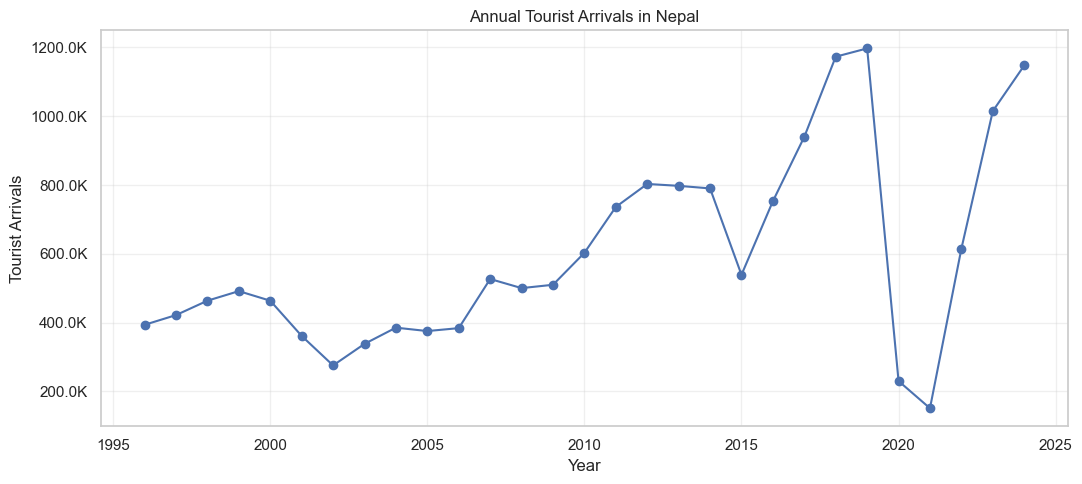

In [6]:
#Section 6: EDA - Line Chart
fig = plot_line_chart(
    master_yearly,
    x="year",
    y="total_arrivals",
    title="Annual Tourist Arrivals in Nepal",
    ylabel="Tourist Arrivals",
    xlabel="Year"
)
plt.show()


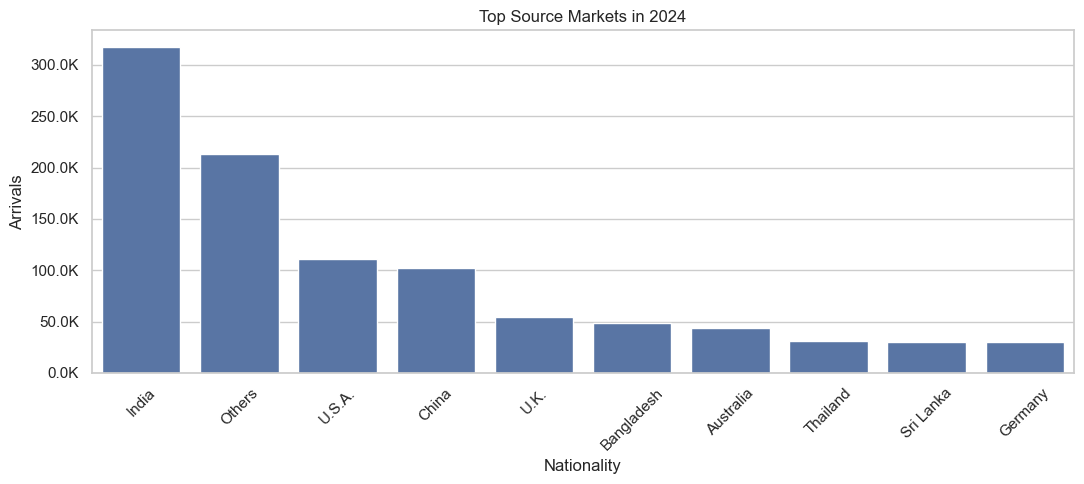

In [7]:
#Section 6: EDA - Bar Chart
latest_year = int(nationality_yearly["year"].max())
latest_markets = nationality_yearly[nationality_yearly["year"] == latest_year]
latest_markets = latest_markets[latest_markets["nationality"] != "Total"].sort_values("arrivals", ascending=False)

fig = plot_bar_chart(
    latest_markets,
    x="nationality",
    y="arrivals",
    title=f"Top Source Markets in {latest_year}",
    ylabel="Arrivals",
    xlabel="Nationality",
    top_n=10
)
plt.show()





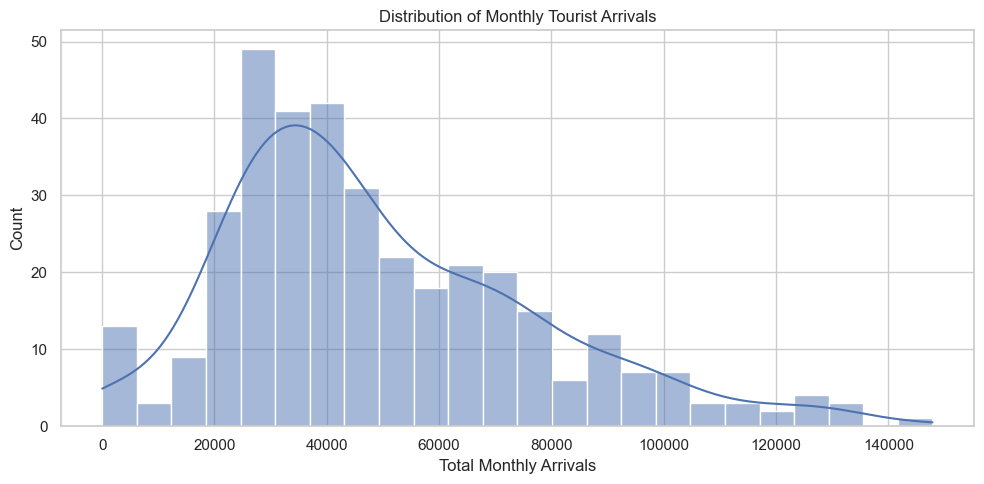

In [8]:
#Section 6: EDA - Histogram
fig = plot_histogram(
    monthly_arrivals,
    column="total_monthly_arrivals",
    title="Distribution of Monthly Tourist Arrivals",
    bins=24
)
plt.show()


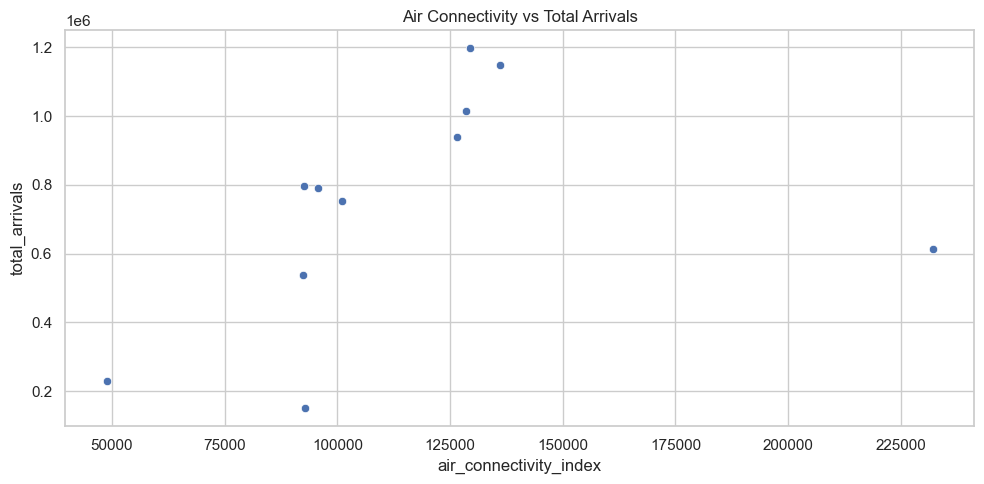

In [9]:
#Section 6: EDA - Scatter Plot
scatter_df = master_yearly.dropna(subset=["air_connectivity_index", "total_arrivals", "bed_count"]).copy()

fig = plot_scatter(
    scatter_df,
    x="air_connectivity_index",
    y="total_arrivals",
    hue=None,
    title="Air Connectivity vs Total Arrivals"
)
plt.show()


In [10]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_multilayer_arrivals_fx

c:\Users\miraj\Downloads\nepal_tourism_dv_project\utils.py:476: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, ax=ax, palette="tab10")


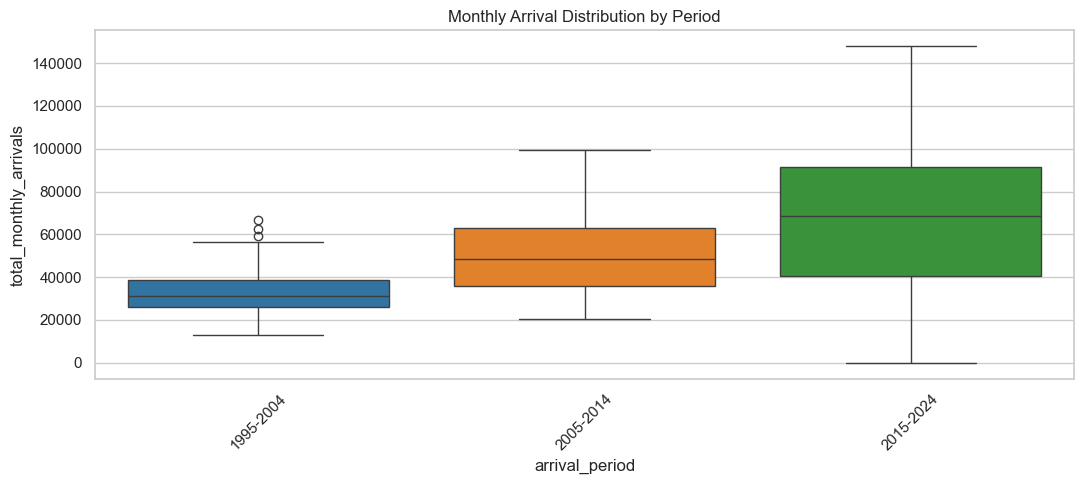

In [11]:
#Section 6: EDA - Boxplot
import importlib
importlib.reload(utils)
from utils import plot_boxplot

monthly_arrivals["arrival_period"] = pd.cut(
    monthly_arrivals["year"],
    bins=[1994, 2004, 2014, 2024],
    labels=["1995-2004", "2005-2014", "2015-2024"]
)

fig = plot_boxplot(
    monthly_arrivals,
    x="arrival_period",
    y="total_monthly_arrivals",
    title="Monthly Arrival Distribution by Period"
)
plt.show()


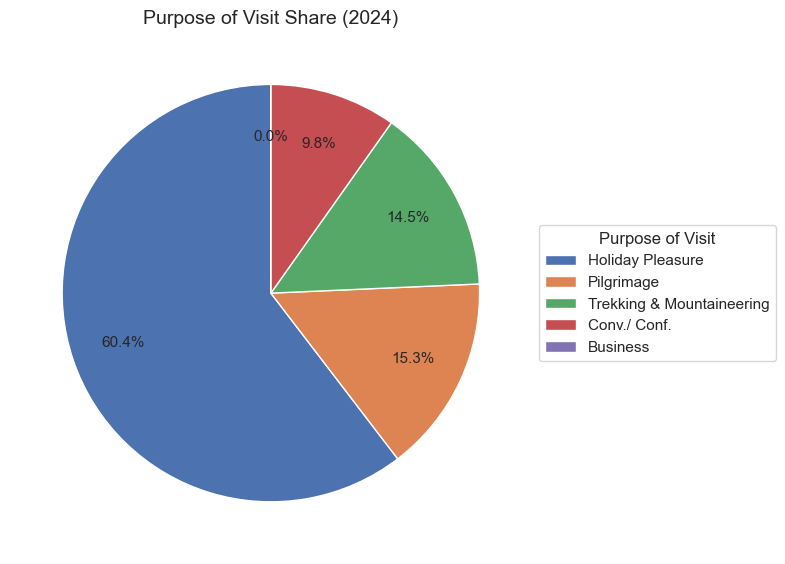

In [12]:
# Purpose of visit mix (FULL PIE - CLEAN)

latest_year_purpose = int(purpose_yearly["year"].max())
purpose_latest = purpose_yearly[purpose_yearly["year"] == latest_year_purpose].copy()

# Keep Top N and group others
TOP_N = 5
purpose_latest = purpose_latest.sort_values("arrivals", ascending=False)

top = purpose_latest.head(TOP_N)
others_sum = purpose_latest.iloc[TOP_N:]["arrivals"].sum()

if others_sum > 0:
    top = pd.concat(
        [
            top,
            pd.DataFrame({"visit_purpose": ["Others"], "arrivals": [others_sum]}),
        ],
        ignore_index=True,
    )

labels = top["visit_purpose"].astype(str)
values = top["arrivals"].astype(float)

plt.figure(figsize=(8, 8))

plt.pie(
    values,
    labels=None,  
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 11},
)


plt.legend(
    labels,
    title="Purpose of Visit",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title(f"Purpose of Visit Share ({latest_year_purpose})", fontsize=14)

plt.tight_layout()
plt.show()

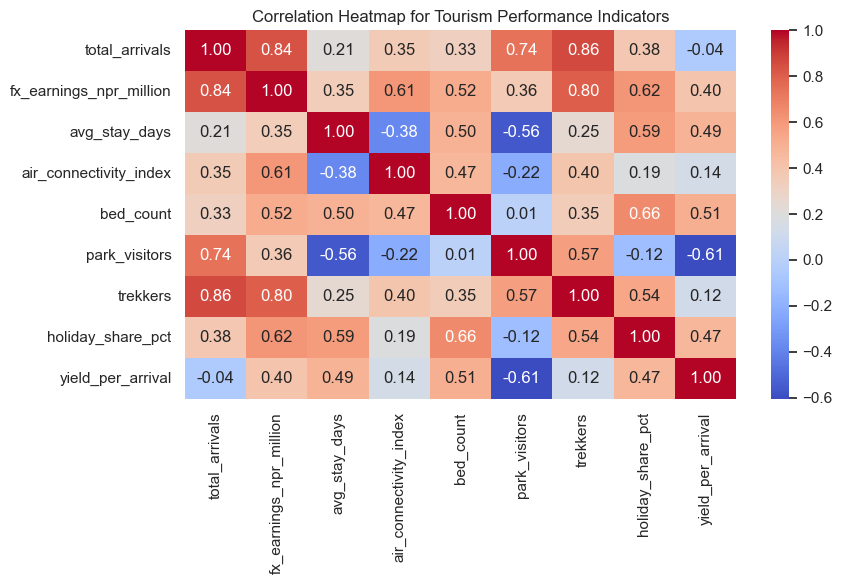

In [13]:
#Section 6: EDA - Heatmap
heat_cols = [
    "total_arrivals", "fx_earnings_npr_million", "avg_stay_days",
    "air_connectivity_index", "bed_count", "park_visitors",
    "trekkers", "holiday_share_pct", "yield_per_arrival"
]

fig = plot_heatmap(
    master_yearly.dropna(subset=["total_arrivals"]),
    columns=[c for c in heat_cols if c in master_yearly.columns],
    title="Correlation Heatmap for Tourism Performance Indicators"
)
plt.show()


In [14]:
#Section 7: Advanced Visualization - Multi-layer Plotly
fig = plot_multilayer_arrivals_fx(master_yearly)
fig.show()


In [15]:
#Section 7: Advanced Visualization - Faceted Chart
fig = plot_faceted_top_markets(nationality_monthly, top_n=6)
fig.show()


In [16]:
#Section 7: Advanced Visualization - Interactive Dropdown
fig = plot_interactive_market_comparison(nationality_yearly)
fig.show()


In [17]:
#Section 7: Advanced Visualization - Tourist Arrivals by Country (Nationality)
import importlib
importlib.reload(utils)
from utils import prepare_arrival_map_data, plot_arrival_choropleth

latest_year = int(master_yearly["year"].max())
arrival_map_data = prepare_arrival_map_data(nationality_yearly, latest_year)

fig2 = plot_arrival_choropleth(arrival_map_data)
fig2.show()


[Arrival map] rows= 18
[Arrival map] unique countries sample: ['India', 'United States', 'China', 'United Kingdom', 'Bangladesh', 'Australia', 'Thailand', 'Sri Lanka', 'Germany', 'South Korea', 'France', 'Japan', 'Malaysia', 'Canada', 'Italy', 'Spain', 'Myanmar', 'Netherlands']


In [18]:
#Section 8: Analytical Views for Reporting
market_yield = nationality_yearly.groupby("nationality", as_index=False).agg(
    total_arrivals=("arrivals", "sum"),
    avg_share=("arrival_pct_share", "mean"),
    estimated_revenue=("estimated_revenue_share_npr_million", "sum"),
    spend_index=("estimated_spend_index", "mean")
).sort_values("estimated_revenue", ascending=False)

market_yield.head(15)

,nationality,total_arrivals,avg_share,estimated_revenue,spend_index
6,India,1890080,23.196364,123311.271600,0.083799
12,Others,1679273,19.920091,107631.558577,0.083957
3,China,918131,9.895455,55448.331410,0.083835
19,U.S.A.,750930,9.309091,49442.105690,0.083812
18,U.K.,636357,5.337273,29612.555910,0.076855
15,Sri Lanka,379976,4.319091,23755.339250,0.083419
16,Thailand,313438,3.830000,19062.529900,0.083827
0,Australia,294551,3.270909,18265.548630,0.083818
5,Germany,240840,2.720000,15294.691180,0.084239
1,Bangladesh,225380,3.118889,13705.635600,0.086711


In [19]:
#Section 9: Export Cleaned Analytical Tables
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

for name, df in tables.items():
    df.to_csv(output_dir / f"{name}.csv", index=False)

print(f"Saved {len(tables)} cleaned analytical tables to {output_dir.resolve()}")


Saved 14 cleaned analytical tables to C:\Users\miraj\Downloads\nepal_tourism_dv_project\outputs
